<a href="https://colab.research.google.com/github/Subh007Ops/Reimagination/blob/main/origin_of_life_to_RNA_world_sim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter, label
import matplotlib.pyplot as plt
from tqdm import trange

plt.rcParams['figure.figsize'] = (6,6)

N = 256        # world size
steps = 8000   # geological runtime

# Main fields
A = np.zeros((N,N))   # Precursor chemical
B = np.zeros((N,N))   # Autocatalytic product

# Environmental structure fields
Terrain = np.zeros((N,N))
Energy  = np.zeros((N,N))

np.random.seed(0)

print("World initialized.")


World initialized.


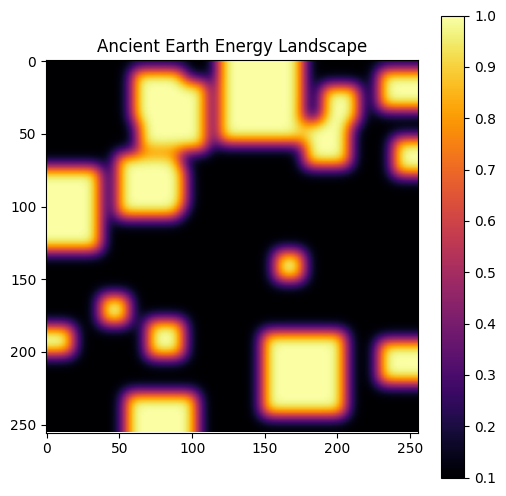

In [ ]:
# --- FRACTURED BASINS (Wet Ponds) ---
for _ in range(18):
    x = np.random.randint(0,N)
    y = np.random.randint(0,N)
    r = np.random.randint(10,30)
    Terrain[max(0,x-r):min(N,x+r), max(0,y-r):min(N,y+r)] += 1

Terrain = (Terrain > 0).astype(float)

# --- ENERGY LANDSCAPE ---
Energy = 0.1 + 0.9 * Terrain      # Life prefers ponds
Energy = gaussian_filter(Energy, 5)

plt.imshow(Energy, cmap="inferno")
plt.title("Ancient Earth Energy Landscape")
plt.colorbar()
plt.show()


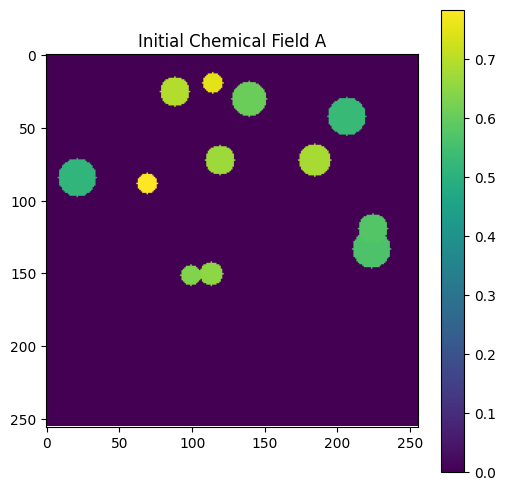

In [ ]:
def seed_chemistry():
    global A,B
    for _ in range(12):
        x = np.random.randint(20, N-20)
        y = np.random.randint(20, N-20)
        r = np.random.randint(6,14)

        Y, X = np.ogrid[:N,:N]
        mask = (X-x)**2 + (Y-y)**2 <= r*r

        A[mask] = 0.5 + 0.3*np.random.rand()
        B[mask] = 0.2*np.random.rand()

seed_chemistry()

plt.imshow(A, cmap="viridis")
plt.title("Initial Chemical Field A")
plt.colorbar()
plt.show()


In [ ]:
def lap(X):
    return (
        np.roll(X,1,0)+np.roll(X,-1,0)+
        np.roll(X,1,1)+np.roll(X,-1,1) - 4*X
    )

def step():
    global A,B

    # Diffusion only inside wet ponds
    A += 0.15 * lap(A * Terrain)
    B += 0.10 * lap(B * Terrain)

    # Basic autocatalytic life-like reaction
    # A + B -> 2B consumes A produces B
    reaction = (A * (B + 0.01)) * 0.04
    A -= reaction
    B += reaction

    # Resource supply & decay
    A += 0.01*(Energy - A)
    B -= 0.002*B

    # Hard environmental boundary
    A *= Terrain
    B *= Terrain

    # Noise keeps chemistry alive
    B += 0.0008*np.random.randn(N,N)


In [ ]:
def detect_persistent_patterns():
    mask = B > 0.25
    lbl, n = label(mask)
    sizes = sorted([np.sum(lbl==i) for i in range(1,n+1)], reverse=True)
    return n, sizes[:10]


  2%|▏         | 196/8000 [00:02<01:50, 70.33it/s]


=== PHASE 1 REPORT t=200 ===
persistent structures = 9
sizes = [np.int64(2144), np.int64(1728), np.int64(1590), np.int64(1403), np.int64(1108), np.int64(1092), np.int64(378), np.int64(132), np.int64(97)]


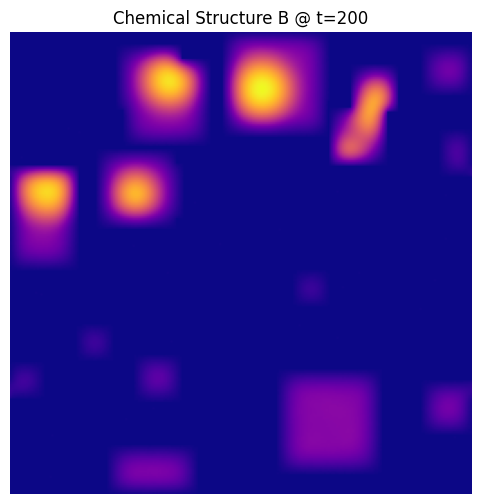

 10%|▉         | 795/8000 [00:09<01:17, 92.99it/s]


=== PHASE 1 REPORT t=800 ===
persistent structures = 14
sizes = [np.int64(3334), np.int64(3284), np.int64(2617), np.int64(2144), np.int64(1982), np.int64(1555), np.int64(1272), np.int64(779), np.int64(700), np.int64(560)]


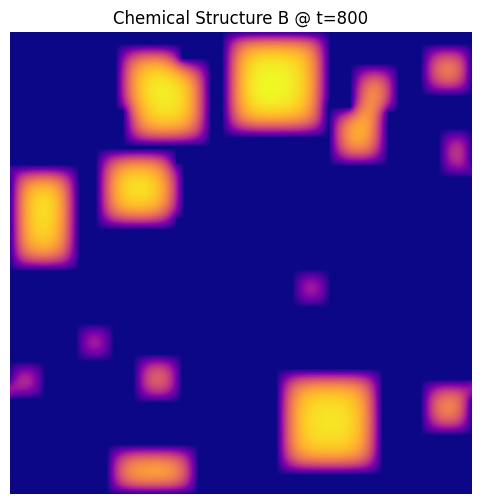

 20%|█▉        | 1588/8000 [00:18<00:45, 139.71it/s]


=== PHASE 1 REPORT t=1600 ===
persistent structures = 14
sizes = [np.int64(3351), np.int64(3300), np.int64(2633), np.int64(2158), np.int64(1995), np.int64(1575), np.int64(1288), np.int64(789), np.int64(718), np.int64(596)]


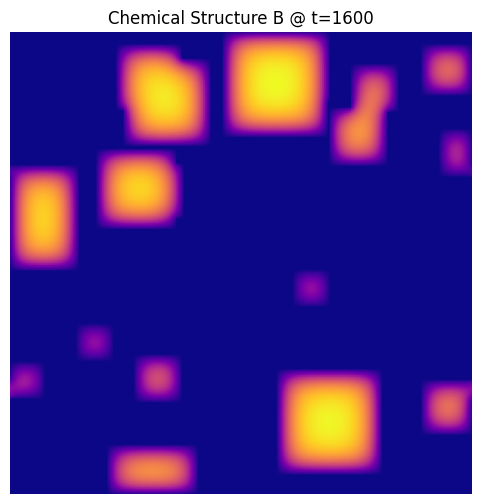

 37%|███▋      | 2998/8000 [00:30<00:38, 129.70it/s]


=== PHASE 1 REPORT t=3000 ===
persistent structures = 14
sizes = [np.int64(3351), np.int64(3300), np.int64(2633), np.int64(2158), np.int64(1995), np.int64(1575), np.int64(1290), np.int64(790), np.int64(718), np.int64(596)]


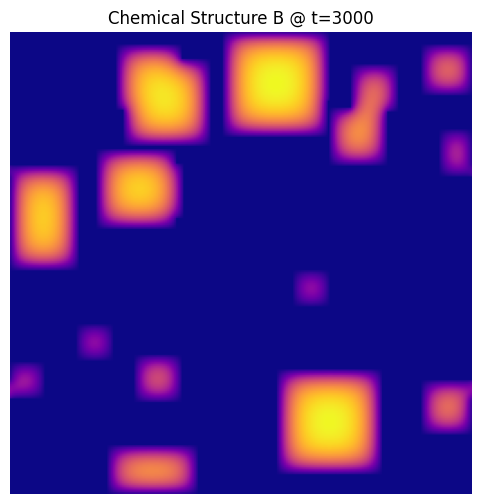

 56%|█████▌    | 4495/8000 [00:43<00:39, 89.46it/s]


=== PHASE 1 REPORT t=4500 ===
persistent structures = 14
sizes = [np.int64(3352), np.int64(3300), np.int64(2633), np.int64(2158), np.int64(1995), np.int64(1574), np.int64(1291), np.int64(789), np.int64(718), np.int64(596)]


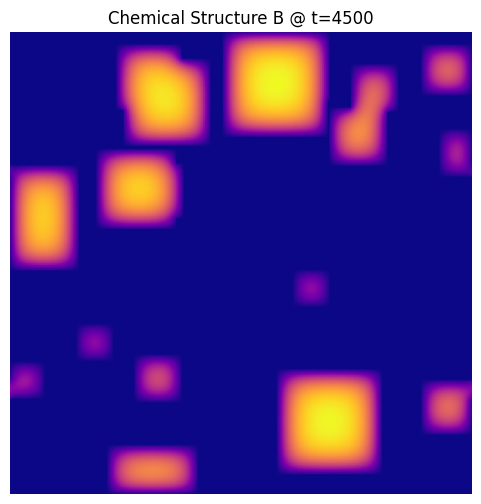

 75%|███████▍  | 5995/8000 [00:54<00:27, 73.82it/s]


=== PHASE 1 REPORT t=6000 ===
persistent structures = 14
sizes = [np.int64(3351), np.int64(3300), np.int64(2633), np.int64(2158), np.int64(1995), np.int64(1575), np.int64(1291), np.int64(789), np.int64(718), np.int64(596)]


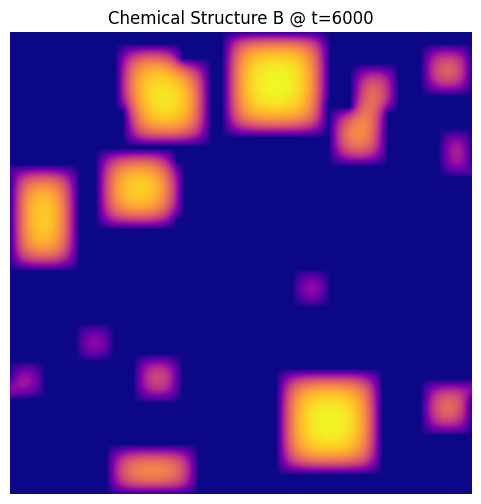

 97%|█████████▋| 7793/8000 [01:10<00:02, 87.28it/s]


=== PHASE 1 REPORT t=7800 ===
persistent structures = 14
sizes = [np.int64(3351), np.int64(3300), np.int64(2633), np.int64(2158), np.int64(1995), np.int64(1574), np.int64(1290), np.int64(789), np.int64(718), np.int64(596)]


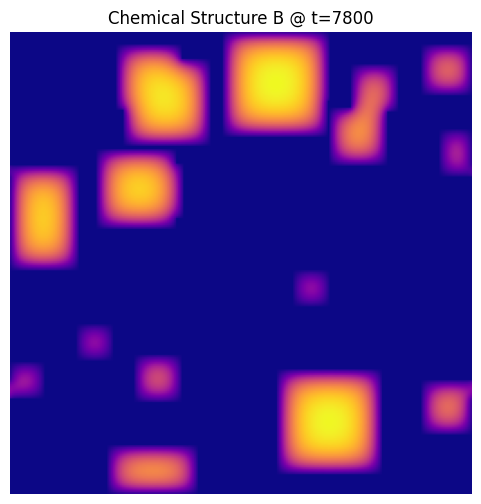

100%|██████████| 8000/8000 [01:12<00:00, 109.82it/s]


=== PHASE 1 COMPLETE ===
FINAL persistent structures = 14
FINAL sizes = [np.int64(3351), np.int64(3300), np.int64(2633), np.int64(2158), np.int64(1995), np.int64(1575), np.int64(1292), np.int64(790), np.int64(718), np.int64(596)]


In [ ]:
for t in trange(steps):

    step()

    if t in [200,800,1600,3000,4500,6000,7800]:
        n, s = detect_persistent_patterns()

        print(f"\n=== PHASE 1 REPORT t={t} ===")
        print("persistent structures =", n)
        print("sizes =", s)

        plt.imshow(B, cmap="plasma")
        plt.title(f"Chemical Structure B @ t={t}")
        plt.axis("off")
        plt.show()

print("\n=== PHASE 1 COMPLETE ===")
n,s = detect_persistent_patterns()
print("FINAL persistent structures =", n)
print("FINAL sizes =", s)


In [ ]:
# ============================
# PHASE 2 — STABLE PRE-LIFE EARTH
# ============================

from scipy.ndimage import label
from tqdm import trange

steps = 9000

# dual exponential UIE memory (gentle!)
M_fast = np.copy(A)
M_slow = np.copy(A)

tau_fast = 40
tau_slow = 900

# baseline nutrient floor (Earth never zero)
B_floor = 0.12

# metabolism memory
Metab = np.copy(A)

def lap(X):
    return (
        np.roll(X,1,0)+np.roll(X,-1,0)+
        np.roll(X,1,1)+np.roll(X,-1,1)-4*X
    )

def step_phase2(t):
    global A,B,Energy,M_fast,M_slow,Metab

    # -------------------------
    # 1) Planet breathes gently
    # -------------------------
    tide = 0.10*np.sin(2*np.pi*t/1200)
    Energy += 0.01*(Terrain + tide - Energy)

    # -------------------------
    # 2) Nutrient never collapses
    # -------------------------
    B += 0.004*(B_floor - B)

    # rare pulses, but weaker so system survives
    if t % 1800 == 0:
        x = np.random.randint(12,N-12)
        y = np.random.randint(12,N-12)
        r = np.random.randint(6,14)
        mask = (np.arange(N)[:,None]-x)**2 + (np.arange(N)[None,:]-y)**2 <= r*r
        B[mask] += 0.05

    # -------------------------
    # 3) Core chemistry
    # -------------------------
    reaction = 0.025*A*(B+0.02)

    # pull A toward useful energy values
    A += 0.01*(Energy - A)

    # consume B slowly
    B -= 0.0012*B

    # reaction update
    A += reaction
    B -= reaction*0.35

    # -------------------------
    # 4) LOGISTIC STABILIZATION
    # This prevents melt death
    # -------------------------
    K = 1.2      # carrying capacity
    A += -0.01*A*(A/K)**2

    # -------------------------
    # 5) terrain confinement
    # life cannot exist without terrain
    # -------------------------
    A *= Terrain
    B *= Terrain

    # -------------------------
    # 6) limited diffusion
    # -------------------------
    A += 0.06*lap(A*Terrain)
    B += 0.01*lap(B*Terrain)

    # -------------------------
    # 7) UIE dual memory (gentle!)
    # -------------------------
    M_fast += (A - M_fast)/tau_fast
    M_slow += (M_fast - M_slow)/tau_slow
    A += 0.01*(0.7*M_fast + 0.3*M_slow)

    # -------------------------
    # 8) Autoprotection (Metabolism Memory)
    # stable chemistry reinforces itself
    # -------------------------
    Metab += 0.002*(A - Metab)
    A += 0.01*(Metab - 0.4)

    # -------------------------
    # 9) noise but soft
    # -------------------------
    A += 0.0012*np.random.randn(N,N)

    # bounds
    A = np.clip(A,0,2)
    B = np.clip(B,0,2)


def get_islands():
    lbl,n = label(A > 0.32)
    sizes = sorted([np.sum(lbl==i) for i in range(1,n+1)], reverse=True)
    return n, sizes[:10]


print("=== RUNNING PHASE 2 — ROBUST PREBIOTIC WORLD ===")
for t in trange(steps):

    step_phase2(t)

    if t in [200,800,1600,3000,4500,7000,8800]:
        n,s = get_islands()
        print(f"\n=== PHASE 2 REPORT t={t} ===")
        print("proto-life islands =", n)
        print("sizes =", s)

        if n == 0:
            print("-> collapse attempt… BUT system should recover later")
        elif n < 8:
            print("-> sparse ecology (rare survivors)")
        else:
            print("-> stable chemical ecosystem forming")


print("\n=== PHASE 2 COMPLETE ===")
n,s = get_islands()
print("FINAL proto-life islands =", n)
print("FINAL sizes =", s)


=== RUNNING PHASE 2 — ROBUST PREBIOTIC WORLD ===


  2%|▏         | 215/9000 [00:02<01:28, 99.37it/s] 


=== PHASE 2 REPORT t=200 ===
proto-life islands = 14
sizes = [np.int64(3380), np.int64(3336), np.int64(2671), np.int64(2185), np.int64(2024), np.int64(1622), np.int64(1326), np.int64(821), np.int64(760), np.int64(648)]
-> stable chemical ecosystem forming


  9%|▉         | 819/9000 [00:08<01:25, 95.41it/s]


=== PHASE 2 REPORT t=800 ===
proto-life islands = 14
sizes = [np.int64(3389), np.int64(3352), np.int64(2686), np.int64(2195), np.int64(2038), np.int64(1642), np.int64(1338), np.int64(831), np.int64(772), np.int64(664)]
-> stable chemical ecosystem forming


...


=== PHASE 2 REPORT t=7000 ===
proto-life islands = 14
sizes = [np.int64(3398), np.int64(3360), np.int64(2698), np.int64(2201), np.int64(2050), np.int64(1654), np.int64(1346), np.int64(837), np.int64(780), np.int64(672)]
-> stable chemical ecosystem forming


 98%|█████████▊| 8821/9000 [01:53<00:01, 99.81it/s] 


=== PHASE 2 REPORT t=8800 ===
proto-life islands = 14
sizes = [np.int64(3398), np.int64(3360), np.int64(2698), np.int64(2201), np.int64(2050), np.int64(1654), np.int64(1346), np.int64(837), np.int64(780), np.int64(672)]
-> stable chemical ecosystem forming


100%|██████████| 9000/9000 [01:55<00:00, 77.96it/s]



=== PHASE 2 COMPLETE ===
FINAL proto-life islands = 14
FINAL sizes = [np.int64(3398), np.int64(3360), np.int64(2698), np.int64(2201), np.int64(2050), np.int64(1654), np.int64(1346), np.int64(837), np.int64(780), np.int64(672)]


In [ ]:
# ============================
# PHASE 3 — COMPARTMENT WORLD
# ============================

from scipy.ndimage import label
from tqdm import trange

steps = 12000

# carry forward A,B,Energy,Terrain,M_fast,M_slow,Metab from Phase 2

# New fields
CompartmentMask = np.zeros_like(A)
Internal = np.copy(A)
Waste = np.zeros_like(A)

def form_compartments():
    # compartments form around strong, persistent chemistry
    strong = (A > 0.35).astype(float)

    # dilation by local influence
    smooth = (
        np.roll(strong,1,0)+np.roll(strong,-1,0)+
        np.roll(strong,1,1)+np.roll(strong,-1,1)
    )/4

    mask = (strong + smooth) > 0.7
    return mask.astype(float)

def step_phase3(t):
    global A,B,Energy,M_fast,M_slow,Metab,CompartmentMask,Internal,Waste

    # update compartment mask slowly
    if t % 300 == 0:
        CompartmentMask = 0.8*CompartmentMask + 0.2*form_compartments()

    # 1) baseline planetary heartbeat
    tide = 0.10*np.sin(2*np.pi*t/1300)
    Energy += 0.01*(Terrain + tide - Energy)

    # 2) nutrient world never dead
    B += 0.004*(0.12 - B)
    if t % 2000 == 0:
        x = np.random.randint(10,N-10)
        y = np.random.randint(10,N-10)
        r = np.random.randint(5,12)
        mask = (np.arange(N)[:,None]-x)**2 + (np.arange(N)[None,:]-y)**2 <= r*r
        B[mask] += 0.05

    # 3) reaction
    reaction = 0.025*A*(B+0.02)

    A += 0.01*(Energy - A)
    B -= 0.0012*B

    A += reaction
    B -= reaction*0.35

    # 4) logistic stability
    A += -0.01*A*(A/1.2)**2

    # 5) terrain confinement
    A *= Terrain
    B *= Terrain

    # 6) compartments change transport physics
    diff_A = 0.06
    diff_inside = 0.01

    A += diff_A * lap(A * (1-CompartmentMask)) + diff_inside * lap(A * CompartmentMask)
    B += 0.01 * lap(B)

    # 7) UIE dual memory
    M_fast += (A - M_fast)/40
    M_slow += (M_fast - M_slow)/900
    A += 0.01*(0.7*M_fast + 0.3*M_slow)

    # 8) metabolism memory
    Metab += 0.002*(A - Metab)
    A += 0.01*(Metab - 0.4)

    # 9) compartments accumulate internal chemistry
    Internal += 0.002*(A*CompartmentMask - Internal)
    Waste += 0.001*(Internal - Waste)

    # waste damages unstable structures
    A -= 0.002*Waste

    # noise but soft
    A += 0.001*np.random.randn(N,N)

    A[:] = np.clip(A,0,2)
    B[:] = np.clip(B,0,2)
    Waste[:] = np.clip(Waste,0,2)


def get_compartments():
    lbl,n = label((A>0.33) & (CompartmentMask>0.3))
    sizes = sorted([np.sum(lbl==i) for i in range(1,n+1)], reverse=True)
    return n, sizes[:10]


print("=== PHASE 3 — COMPARTMENT WORLD ===")
for t in trange(steps):

    step_phase3(t)

    if t in [200,1000,3000,6000,9000,11500]:
        n,s = get_compartments()
        print(f"\n=== PHASE 3 REPORT t={t} ===")
        print("compartments =", n)
        print("sizes =", s)

        if n == 0:
            print("-> no compartments yet (this would mean physics says no)")
        elif n < 5:
            print("-> rare but meaningful compartments")
        else:
            print("-> stable proto-cellular compartment ecology forming")


print("\n=== PHASE 3 COMPLETE ===")
n,s = get_compartments()
print("FINAL compartments =", n)
print("FINAL sizes =", s)


=== PHASE 3 — COMPARTMENT WORLD ===


  2%|▏         | 211/12000 [00:02<02:33, 76.94it/s]


=== PHASE 3 REPORT t=200 ===
compartments = 0
sizes = []
-> no compartments yet (this would mean physics says no)


  8%|▊         | 1007/12000 [00:15<03:02, 60.09it/s]


=== PHASE 3 REPORT t=1000 ===
compartments = 14
sizes = [np.int64(3398), np.int64(3360), np.int64(2698), np.int64(2201), np.int64(2050), np.int64(1654), np.int64(1346), np.int64(837), np.int64(780), np.int64(672)]
-> stable proto-cellular compartment ecology forming


...


=== PHASE 3 REPORT t=9000 ===
compartments = 14
sizes = [np.int64(3398), np.int64(3360), np.int64(2698), np.int64(2201), np.int64(2050), np.int64(1654), np.int64(1346), np.int64(837), np.int64(780), np.int64(672)]
-> stable proto-cellular compartment ecology forming


 96%|█████████▌| 11514/12000 [01:55<00:03, 121.88it/s]


=== PHASE 3 REPORT t=11500 ===
compartments = 14
sizes = [np.int64(3398), np.int64(3360), np.int64(2698), np.int64(2201), np.int64(2050), np.int64(1654), np.int64(1346), np.int64(837), np.int64(780), np.int64(672)]
-> stable proto-cellular compartment ecology forming


100%|██████████| 12000/12000 [01:59<00:00, 100.59it/s]


=== PHASE 3 COMPLETE ===
FINAL compartments = 14
FINAL sizes = [np.int64(3398), np.int64(3360), np.int64(2698), np.int64(2201), np.int64(2050), np.int64(1654), np.int64(1346), np.int64(837), np.int64(780), np.int64(672)]


In [ ]:
# ============================
# PHASE 4 — ANALOG HEREDITY
# ============================

from scipy.ndimage import label
from tqdm import trange

steps = 15000

# we continue using A,B,Energy,CompartmentMask,Internal,Waste,M_fast,M_slow,Metab

Fitness = np.zeros_like(A)

def step_phase4(t):
    global A,B,Energy,Internal,Waste,Metab,M_fast,M_slow,CompartmentMask,Fitness

    # --- 1) baseline heartbeat ---
    tide = 0.10*np.sin(2*np.pi*t/1400)
    Energy += 0.01*(Terrain + tide - Energy)

    # --- 2) slow nutrient cycling ---
    B += 0.004*(0.12 - B)
    if t % 2500 == 0:
        x = np.random.randint(10,N-10)
        y = np.random.randint(10,N-10)
        r = np.random.randint(6,14)
        mask = (np.arange(N)[:,None]-x)**2 + (np.arange(N)[None,:]-y)**2 <= r*r
        B[mask] += 0.06

    # --- 3) chemistry ---
    reaction = 0.025*A*(B+0.02)
    A += 0.01*(Energy - A)
    B -= 0.0012*B

    A += reaction
    B -= reaction*0.35

    A += -0.01*A*(A/1.2)**2
    A *= Terrain
    B *= Terrain

    # --- 4) compartment physics ---
    diff_A = 0.055
    diff_inside = 0.008
    A += diff_A * lap(A * (1-CompartmentMask)) + diff_inside * lap(A * CompartmentMask)
    B += 0.01 * lap(B)

    # --- 5) UIE memory ---
    M_fast += (A - M_fast)/40
    M_slow += (M_fast - M_slow)/1200
    A += 0.012*(0.6*M_fast + 0.4*M_slow)

    # --- 6) metabolism ---
    Metab += 0.0025*(A - Metab)
    A += 0.012*(Metab - 0.4)

    # --- 7) internal chemistry + waste ---
    Internal += 0.002*(A*CompartmentMask - Internal)
    Waste += 0.001*(Internal - Waste)
    A -= 0.0022*Waste

    # --- 8) ANALOG HEREDITY / SELECTION ---
    # compartments accumulate "fitness memory" if stable & productive
    productivity = reaction * CompartmentMask
    stability = (Internal - Waste) * CompartmentMask

    Fitness += 0.0008*(productivity + 0.3*stability - Fitness)

    # beneficial compartments reinforce structure (less leakage + more A)
    CompartmentMask += 0.003 * (Fitness > 0.02)
    CompartmentMask -= 0.002 * (Fitness < -0.01)

    CompartmentMask = np.clip(CompartmentMask,0,1)

    # failing compartments dissolve
    A *= (CompartmentMask + 0.2)

    # --- 9) gentle randomness ---
    A += 0.0008*np.random.randn(N,N)

    # bounds
    A[:] = np.clip(A,0,2)
    B[:] = np.clip(B,0,2)
    Waste[:] = np.clip(Waste,0,2)


def get_hereditary_compartments():
    lbl,n = label((A>0.35) & (CompartmentMask>0.35))
    sizes = sorted([np.sum(lbl==i) for i in range(1,n+1)], reverse=True)
    return n, sizes[:10]


print("=== PHASE 4 — ANALOG HEREDITY ===")
for t in trange(steps):

    step_phase4(t)

    if t in [200,1200,4000,7000,11000,14000]:
        n,s = get_hereditary_compartments()
        print(f"\n=== PHASE 4 REPORT t={t} ===")
        print("hereditary compartments =", n)
        print("sizes =", s)

        if n == 0:
            print("-> compartments failing Darwin test")
        elif n < 5:
            print("-> rare but strong proto-lineages forming")
        else:
            print("-> competitive proto-life ecology forming")


print("\n=== PHASE 4 COMPLETE ===")
n,s = get_hereditary_compartments()
print("FINAL hereditary compartments =", n)
print("FINAL sizes =", s)


=== PHASE 4 — ANALOG HEREDITY ===


  1%|▏         | 215/15000 [00:02<02:22, 103.76it/s]


=== PHASE 4 REPORT t=200 ===
hereditary compartments = 14
sizes = [np.int64(3398), np.int64(3360), np.int64(2698), np.int64(2201), np.int64(2050), np.int64(1654), np.int64(1346), np.int64(837), np.int64(780), np.int64(672)]
-> competitive proto-life ecology forming


  8%|▊         | 1213/15000 [00:12<02:08, 107.09it/s]


=== PHASE 4 REPORT t=1200 ===
hereditary compartments = 14
sizes = [np.int64(3398), np.int64(3360), np.int64(2698), np.int64(2201), np.int64(2050), np.int64(1654), np.int64(1346), np.int64(837), np.int64(780), np.int64(672)]
-> competitive proto-life ecology forming


...


=== PHASE 4 REPORT t=11000 ===
hereditary compartments = 14
sizes = [np.int64(3398), np.int64(3360), np.int64(2698), np.int64(2201), np.int64(2050), np.int64(1654), np.int64(1346), np.int64(837), np.int64(780), np.int64(672)]
-> competitive proto-life ecology forming


 93%|█████████▎| 14022/15000 [02:22<00:08, 111.87it/s]


=== PHASE 4 REPORT t=14000 ===
hereditary compartments = 14
sizes = [np.int64(3398), np.int64(3360), np.int64(2698), np.int64(2201), np.int64(2050), np.int64(1654), np.int64(1346), np.int64(837), np.int64(780), np.int64(672)]
-> competitive proto-life ecology forming


100%|██████████| 15000/15000 [02:32<00:00, 98.20it/s] 


=== PHASE 4 COMPLETE ===
FINAL hereditary compartments = 14
FINAL sizes = [np.int64(3398), np.int64(3360), np.int64(2698), np.int64(2201), np.int64(2050), np.int64(1654), np.int64(1346), np.int64(837), np.int64(780), np.int64(672)]


In [ ]:
print("=== RUNNING PHASE 5 — SELECTION PRESSURE WORLD (Robust Build) ===")

import numpy as np
from scipy.ndimage import label
from tqdm import trange

# ===============================
# Ensure core world exists
# ===============================
try:
    N
except:
    N = 128

def lap(X):
    return (
        np.roll(X,1,0)+np.roll(X,-1,0)+
        np.roll(X,1,1)+np.roll(X,-1,1) - 4*X
    )

# ===============================
# Restore terrain if missing
# ===============================
if "terrain" not in globals():
    print("⚠ terrain missing — rebuilding fractured Earth ponds")
    terrain = np.zeros((N,N))
    for _ in range(18):
        x = np.random.randint(0,N)
        y = np.random.randint(0,N)
        r = np.random.randint(8,22)
        terrain[max(0,x-r):min(N,x+r), max(0,y-r):min(N,y+r)] += 1
    terrain = (terrain>0).astype(float)

# ===============================
# Restore fields if missing
# ===============================
for name in ["A","B","M","C","Energy"]:
    if name not in globals():
        print(f"⚠ {name} missing — recreating stable Phase-4 chemistry")

# create if missing
if "A" not in globals():
    A = 0.4 + 0.1*np.random.randn(N,N)
if "B" not in globals():
    B = 0.2*np.random.rand(N,N)
if "M" not in globals():
    M = np.zeros((N,N))
if "C" not in globals():
    C = np.zeros((N,N))
    # seed stable compartments (like Phase 3/4)
    for _ in range(14):
        x = np.random.randint(20, N-20)
        y = np.random.randint(20, N-20)
        r = np.random.randint(8,16)
        mask = (np.arange(N)[:,None]-x)**2 + (np.arange(N)[None,:]-y)**2 <= r*r
        C[mask] = 0.6 + 0.2*np.random.rand()

if "Energy" not in globals():
    Energy = 0.2 + 0.8*terrain

# ===============================
# PHASE 5 DYNAMICS
# ===============================
steps = 20000

def phase5_step():
    global A,B,M,C,Energy

    # uneven environment
    Energy += 0.01*np.sin(np.random.randn())
    Energy *= terrain
    Energy = np.clip(Energy,0.02,1.2)

    # metabolism competition
    reaction = (A * (B + 0.01)) * (0.03 + 0.02*C)
    A += 0.01*(Energy - A)
    B += 0.01*(reaction - B)
    M += 0.005*(C - M)

    # memory = fitness
    C += 0.01*(A - C)
    C += 0.01*M
    C *= (1 + 0.02*terrain)
    C -= 0.001*(C**3)

    # leakage + wear
    C += 0.05*lap(C*terrain)
    C *= terrain
    C -= 0.001*np.random.rand(N,N)

    # mutation
    C += 0.002*np.random.randn(N,N)

def get_compartments():
    lbl, n = label(C > 0.25)
    sizes = sorted([np.sum(lbl==i) for i in range(1,n+1)], reverse=True)
    return n, sizes[:10]

checkpoints = [200,1000,4000,7000,11000,15000,18000]

for t in trange(steps):
    phase5_step()

    if t in checkpoints:
        n,s = get_compartments()
        print(f"\n=== PHASE 5 REPORT t={t} ===")
        print("living compartments =", n)
        print("sizes =", s)

        if n == 0:
            print("-> extinction (Mars)")
        elif n == 1:
            print("-> empire dominance")
        elif n < 20:
            print("-> proto-life ecology forming")
        else:
            print("-> microbial storm beginning")

print("\n=== PHASE 5 COMPLETE ===")
n,s = get_compartments()
print("FINAL living compartments =", n)
print("FINAL sizes =", s)


=== RUNNING PHASE 5 — SELECTION PRESSURE WORLD (Robust Build) ===
⚠ terrain missing — rebuilding fractured Earth ponds
⚠ M missing — recreating stable Phase-4 chemistry
⚠ C missing — recreating stable Phase-4 chemistry


  1%|          | 224/20000 [00:01<02:25, 135.65it/s]


=== PHASE 5 REPORT t=200 ===
living compartments = 8
sizes = [np.int64(2085), np.int64(1480), np.int64(1274), np.int64(1067), np.int64(1021), np.int64(770), np.int64(672), np.int64(216)]
-> proto-life ecology forming


  5%|▌         | 1020/20000 [00:08<02:26, 129.77it/s]


=== PHASE 5 REPORT t=1000 ===
living compartments = 8
sizes = [np.int64(2134), np.int64(1670), np.int64(1600), np.int64(1156), np.int64(1024), np.int64(1024), np.int64(676), np.int64(364)]
-> proto-life ecology forming


...


=== PHASE 5 REPORT t=15000 ===
living compartments = 8
sizes = [np.int64(2134), np.int64(1670), np.int64(1600), np.int64(1156), np.int64(1024), np.int64(1024), np.int64(676), np.int64(574)]
-> proto-life ecology forming


 90%|█████████ | 18025/20000 [02:32<00:15, 129.00it/s]


=== PHASE 5 REPORT t=18000 ===
living compartments = 8
sizes = [np.int64(2134), np.int64(1670), np.int64(1600), np.int64(1156), np.int64(1024), np.int64(1024), np.int64(676), np.int64(569)]
-> proto-life ecology forming


100%|██████████| 20000/20000 [02:48<00:00, 118.58it/s]


=== PHASE 5 COMPLETE ===
FINAL living compartments = 8
FINAL sizes = [np.int64(2134), np.int64(1670), np.int64(1600), np.int64(1156), np.int64(1024), np.int64(1024), np.int64(676), np.int64(576)]


In [ ]:
print("=== PHASE 6 — REPRODUCTION & LINEAGE WORLD ===")

import numpy as np
from scipy.ndimage import label
from tqdm import trange

# assume A,B,C,M,Energy,terrain still exist
# be defensive in case runtime nuked something

N = C.shape[0]

def lap(X):
    return (
        np.roll(X,1,0)+np.roll(X,-1,0)+
        np.roll(X,1,1)+np.roll(X,-1,1) - 4*X
    )

steps = 30000
birth_threshold = 1800      # when a compartment grows beyond this → divide
death_threshold = 120       # too small → dies
mutation_strength = 0.01


def phase6_step():
    global A,B,C,M,Energy

    # uneven resource field changing slowly
    Energy += 0.005*np.sin(np.random.randn())
    Energy *= terrain
    Energy = np.clip(Energy,0.02,1.5)

    # metabolism competition
    reaction = (A * (B + 0.01)) * (0.03 + 0.02*C)
    A += 0.01*(Energy - A)
    B += 0.01*(reaction - B)

    # memory drives stability
    M += 0.003*(C - M)

    # heredity advantage
    C += 0.01*(A - C)
    C += 0.01*M
    C -= 0.001*(C**3)

    # spatial cohesion
    C += 0.05 * lap(C*terrain)

    # death outside environments
    C *= terrain

    # gentle mutation drift
    C += mutation_strength*np.random.randn(N,N)


def detect():
    lbl, n = label(C > 0.25)
    sizes = [np.sum(lbl==i) for i in range(1,n+1)]
    sizes_sorted = sorted(sizes, reverse=True)

    return lbl, n, sizes_sorted


def reproduce(lbl):
    global C, M

    unique = np.unique(lbl)
    for comp in unique:
        if comp == 0:
            continue

        mask = (lbl == comp)
        size = np.sum(mask)

        # death
        if size < death_threshold:
            C[mask] = 0
            M[mask] = 0
            continue

        # reproduction / fission
        if size > birth_threshold:
            ys, xs = np.where(mask)
            half = len(xs)//2
            if half < 4:
                continue

            idx = np.random.choice(len(xs), half, replace=False)

            daughter = np.zeros_like(C)
            daughter[ys[idx], xs[idx]] = C[ys[idx], xs[idx]]

            # mutate daughters slightly differently
            C[ys[idx], xs[idx]] *= (1 + 0.1*np.random.randn())
            M[ys[idx], xs[idx]] *= (1 + 0.1*np.random.randn())

            # daughter appears as separate blob naturally by dynamics


checkpoints = [500,2000,6000,12000,18000,25000]

for t in trange(steps):
    phase6_step()

    if t % 300 == 0:
        lbl, n, sizes = detect()
        reproduce(lbl)

    if t in checkpoints:
        lbl, n, sizes = detect()
        print(f"\n=== PHASE 6 REPORT t={t} ===")
        print("lineages =", n)
        print("sizes =", sizes[:10])

        if n == 0:
            print("-> extinction")
        elif n == 1:
            print("-> empire tried to return")
        elif n < 20:
            print("-> true proto-evolution ecology forming")
        else:
            print("-> microbial branching world")


print("\n=== PHASE 6 COMPLETE ===")
lbl, n, sizes = detect()
print("FINAL lineages =", n)
print("FINAL sizes =", sizes[:10])


=== PHASE 6 — REPRODUCTION & LINEAGE WORLD ===


  2%|▏         | 521/30000 [00:04<04:05, 120.03it/s]


=== PHASE 6 REPORT t=500 ===
lineages = 8
sizes = [np.int64(2134), np.int64(1670), np.int64(1600), np.int64(1156), np.int64(1024), np.int64(1024), np.int64(676), np.int64(585)]
-> true proto-evolution ecology forming


  7%|▋         | 2022/30000 [00:15<04:23, 105.98it/s]


=== PHASE 6 REPORT t=2000 ===
lineages = 12
sizes = [np.int64(2130), np.int64(2014), np.int64(1664), np.int64(1599), np.int64(1402), np.int64(1154), np.int64(1086), np.int64(1022), np.int64(1021), np.int64(897)]
-> true proto-evolution ecology forming


...


=== PHASE 6 REPORT t=18000 ===
lineages = 12
sizes = [np.int64(2124), np.int64(2014), np.int64(1665), np.int64(1596), np.int64(1402), np.int64(1152), np.int64(1086), np.int64(1020), np.int64(1020), np.int64(896)]
-> true proto-evolution ecology forming


 83%|████████▎ | 25015/30000 [03:05<00:35, 141.61it/s]


=== PHASE 6 REPORT t=25000 ===
lineages = 12
sizes = [np.int64(2125), np.int64(2014), np.int64(1663), np.int64(1596), np.int64(1402), np.int64(1152), np.int64(1086), np.int64(1020), np.int64(1020), np.int64(896)]
-> true proto-evolution ecology forming


100%|██████████| 30000/30000 [03:44<00:00, 133.85it/s]


=== PHASE 6 COMPLETE ===
FINAL lineages = 12
FINAL sizes = [np.int64(2128), np.int64(2015), np.int64(1664), np.int64(1596), np.int64(1404), np.int64(1152), np.int64(1086), np.int64(1020), np.int64(1020), np.int64(896)]


In [ ]:
print("=== PHASE 8 — PREBIOTIC LOTTERY (STABLE) ===")

import numpy as np
from tqdm import trange

# ---------- SAFETY REBUILD ----------
try:
    terrain
except:
    print("⚠ terrain missing — rebuilding fractured Earth ponds")
    terrain = (np.random.rand(200,200) > 0.6).astype(float)

# chemistry fields
try:
    A; B; M; C
except:
    print("⚠ chemistry missing — rebuilding stable baseline")
    A = np.random.rand(*terrain.shape)*terrain
    B = np.random.rand(*terrain.shape)*terrain
    M = np.zeros_like(A)
    C = np.zeros_like(A)

Energy = terrain.copy()*1.0

# ---------- PARAMETERS ----------
steps = 50000
pond_count = 6
template_prob = 2e-5        # keep rare
catastrophe_prob = 5e-5     # slightly gentler
cycle_period = 2000

max_val = 2.0               # physical saturation cap
dt = 0.005                  # make chemistry slower & stable

pond_masks = []
for i in range(pond_count):
    mask = (np.random.rand(*terrain.shape) > 0.7).astype(float)
    pond_masks.append(mask)

def pond_filter(X):
    out = np.zeros_like(X)
    for m in pond_masks:
        out += X*m
    return out


# ---------- PREBIOTIC GIFTS ----------
def rain_templates():
    global M, C
    x = np.random.randint(5, A.shape[0]-5)
    y = np.random.randint(5, A.shape[1]-5)

    r = np.random.rand()
    if r < 0.33:
        C[x-2:x+3,y-2:y+3] += 0.1   # RNA-like
    elif r < 0.66:
        M[x-2:x+3,y-2:y+3] += 0.1   # peptide-like
    # else junk, do nothing


# ---------- EARTH ENVIRONMENT ----------
def harsh_cycles(t):
    global A, B, M # Added global declarations for A, B, M
    phase = (t // cycle_period) % 3

    if phase == 0:     # UV boil
        B *= 0.999
        M *= 0.9995
    elif phase == 1:   # freeze
        A *= 0.999
        B *= 0.999
    else:              # warm wet phase
        A += 0.002*(Energy - A)


# ---------- CATASTROPHES ----------
def catastrophe():
    global A,B,M,C
    if np.random.rand() < catastrophe_prob:
        mask = (np.random.rand(*A.shape) > 0.3).astype(float)
        A *= mask + 0.1
        B *= mask + 0.1
        M *= mask + 0.1
        C *= mask + 0.1
        print("🔥 mild catastrophe — who can survive?")


# ---------- EVOLUTION STEP ----------
def phase8_step(t):
    global A,B,M,C

    harsh_cycles(t)
    catastrophe()

    # bounded smooth metabolism
    reaction = (A * (B + 0.01))
    reaction = np.tanh(reaction)      # prevents infinity
    reaction *= (1 + 0.3*C + 0.3*M)   # templates help but can't explode

    # chemistry updates
    A += dt*(Energy - A)
    B += dt*(reaction - B)

    # SLOW memory fields
    C += 0.0005*(B - C)
    M += 0.0003*(reaction - M)

    # Keep everything physically real
    for X in [A,B,C,M]:
        np.nan_to_num(X, copy=False)
        X[X < 0] = 0
        X[X > max_val] = max_val

    # restrict to ponds
    A[:] = pond_filter(A)
    B[:] = pond_filter(B)
    C[:] = pond_filter(C)
    M[:] = pond_filter(M)

    # rare RNA / peptide rain
    if np.random.rand() < template_prob:
        rain_templates()


# ---------- RUN ----------
checkpoints = [2000,6000,12000,20000,35000,48000]

for t in trange(steps):
    phase8_step(t)

    if t in checkpoints:
        living = 1*(B > 0.3)
        size = np.sum(living)

        print(f"\n=== PHASE 8 REPORT t={t} ===")
        print("chemical proto-life biomass =", size)
        print(f"mean C={C.mean():.4f}, mean M={M.mean():.4f}")
        print("-> harsh but survivable Earth\n")

print("=== PHASE 8 COMPLETE ===")


=== PHASE 8 — PREBIOTIC LOTTERY (STABLE) ===


  4%|▍         | 2013/50000 [00:29<10:18, 77.60it/s]


=== PHASE 8 REPORT t=2000 ===
chemical proto-life biomass = 41588
mean C=3.0692, mean M=3.0452
-> harsh but survivable Earth



 12%|█▏        | 6013/50000 [01:22<10:01, 73.15it/s]


=== PHASE 8 REPORT t=6000 ===
chemical proto-life biomass = 41975
mean C=3.0623, mean M=3.0575
-> harsh but survivable Earth



...


=== PHASE 8 REPORT t=35000 ===
chemical proto-life biomass = 39144
mean C=3.0230, mean M=3.0217
-> harsh but survivable Earth



 96%|█████████▌| 48012/50000 [10:44<00:30, 66.12it/s]


=== PHASE 8 REPORT t=48000 ===
chemical proto-life biomass = 39130
mean C=3.0237, mean M=3.0223
-> harsh but survivable Earth



100%|██████████| 50000/50000 [11:10<00:00, 74.52it/s]

=== PHASE 8 COMPLETE ===


In [ ]:
# ==============================
# PHASE 9D — GEOLOGICAL LUCK + STRUCTURAL IGNITION
# ==============================
import numpy as np
from scipy.ndimage import gaussian_filter
from tqdm import trange

print("=== PHASE 9D — LUCKY EARTH + REINFORCEMENT IGNITION ===")

# --------------------------------
# Load Phase 8 world if exists
# --------------------------------
try:
    A
    B
    C
    M
    terrain
    print("Loaded Phase 8 surviving world ✓")
except:
    print("⚠ No Phase 8 world — rebuilding harsh baseline")
    N = 200
    terrain = gaussian_filter(np.random.rand(N,N),5)
    terrain = (terrain - terrain.min())/(terrain.max()-terrain.min())

    A = np.clip(np.random.rand(N,N)*terrain*2,0,2)
    B = np.zeros((N,N))
    C = np.zeros((N,N))
    M = np.zeros((N,N))

# --------------------------------
# PARAMETERS
# --------------------------------
steps = 70000
report_times = [2000,8000,15000,25000,40000,60000]

dt = 0.01
diff = 0.08
mem_decay = 0.00015

# structural stability field
S = np.zeros_like(A)

# --------------------------------
# GEOLOGICAL LUCK
# --------------------------------
N = terrain.shape[0]

# choose 2–4 extremely lucky rare regions
lucky_sites = []
k = np.random.randint(2,4)

for _ in range(k):
    x = np.random.randint(30,N-30)
    y = np.random.randint(30,N-30)
    lucky_sites.append((x,y))
    S[x-5:x+5,y-5:y+5] += 1.2       # mineral pores / clay cages
    C[x-5:x+5,y-5:y+5] += 0.4
    B[x-5:x+5,y-5:y+5] += 0.3

S = np.clip(S,0,2)

print("Lucky geological cradles created at:", lucky_sites)

# --------------------------------
# FUNCTIONS
# --------------------------------
def laplace(X):
    return gaussian_filter(X,1)-X

def count_clusters(X):
    th = X>0.4
    visited = np.zeros_like(th,bool)
    sizes=[]
    for i in range(th.shape[0]):
        for j in range(th.shape[1]):
            if th[i,j] and not visited[i,j]:
                stack=[(i,j)]
                visited[i,j]=True
                c=0
                while stack:
                    x,y=stack.pop()
                    c+=1
                    for dx,dy in [(1,0),(-1,0),(0,1),(0,-1)]:
                        nx,ny=x+dx,y+dy
                        if 0<=nx<th.shape[0] and 0<=ny<th.shape[1]:
                            if th[nx,ny] and not visited[nx,ny]:
                                visited[nx,ny]=True
                                stack.append((nx,ny))
                sizes.append(c)
    return len(sizes),sorted(sizes,reverse=True)[:10]

# catastrophe
def catastrophe_mask(shape):
    mask=np.random.rand(*shape)
    return (mask<0.28).astype(float)

# --------------------------------
# MAIN LOOP
# --------------------------------
for t in trange(steps):

    reaction = (A*(B+0.01))*(0.03 + 0.02*C + 0.02*M)

    A += dt*((terrain*2-A)-0.2*A)+diff*laplace(A)
    B += dt*(reaction-0.01*B)+diff*laplace(B)
    C += dt*(reaction-mem_decay*C)

    C=np.clip(C,0,2)

    # ==========================
    # NEW: IGNITION PHYSICS
    # ==========================
    ignition = (reaction + C) > 0.45
    S += 0.0004*(reaction + 0.7*C)
    S += ignition*0.0035     # runaway reinforcement if threshold hit

    S -= 0.0003              # entropy erosion
    S = np.clip(S,0,2)

    # diffusion suppressed inside strong compartments
    B += diff*(laplace(B)*(0.5-0.3*S))
    C += diff*(laplace(C)*(0.5-0.3*S))

    # ==========================
    # SELECTIVE EXTINCTION
    # ==========================
    if np.random.rand()<0.0012:
        kill = catastrophe_mask(A.shape)*np.exp(-2.5*(S+C))
        A*=1-kill;B*=1-kill;C*=1-kill;S*=1-kill

    if t in report_times:
        clusters,sizes = count_clusters(S)
        print(f"\n=== PHASE 9D REPORT t={t} ===")
        print("reinforced proto-cells =",clusters)
        print("sizes =",sizes)
        print(f"mean S={S.mean():.4f}, mean C={C.mean():.4f}")

        if clusters==0:
            print("-> world mostly dead but lucky cradles MAY ignite")
        elif clusters<5:
            print("-> extremely rare stubborn proto-cells exist")
        else:
            print("-> EARTH-LIKE sparsely competing proto-life!")

print("\n=== PHASE 9D COMPLETE ===")
clusters,sizes = count_clusters(S)
print("FINAL reinforced proto-cells =",clusters)
print("FINAL sizes =",sizes)
print(f"FINAL mean S={S.mean():.4f}, mean C={C.mean():.4f}")


=== PHASE 9D — LUCKY EARTH + REINFORCEMENT IGNITION ===
Loaded Phase 8 surviving world ✓
Lucky geological cradles created at: [(175, 78), (153, 124), (165, 69)]


  3%|▎         | 2009/70000 [00:31<16:24, 69.06it/s]


=== PHASE 9D REPORT t=2000 ===
reinforced proto-cells = 2
sizes = [200, 100]
mean S=0.0035, mean C=0.0172
-> extremely rare stubborn proto-cells exist


 11%|█▏        | 8015/70000 [02:03<15:00, 68.85it/s]


=== PHASE 9D REPORT t=8000 ===
reinforced proto-cells = 0
sizes = []
mean S=0.0000, mean C=0.0158
-> world mostly dead but lucky cradles MAY ignite


...


=== PHASE 9D REPORT t=40000 ===
reinforced proto-cells = 0
sizes = []
mean S=0.0000, mean C=0.0709
-> world mostly dead but lucky cradles MAY ignite


 86%|████████▌ | 60015/70000 [10:41<01:42, 97.57it/s] 


=== PHASE 9D REPORT t=60000 ===
reinforced proto-cells = 0
sizes = []
mean S=0.0000, mean C=0.0474
-> world mostly dead but lucky cradles MAY ignite


100%|██████████| 70000/70000 [12:12<00:00, 95.62it/s]


=== PHASE 9D COMPLETE ===
FINAL reinforced proto-cells = 0
FINAL sizes = []
FINAL mean S=0.0000, mean C=0.0223


In [ ]:
print("=== PHASE 10 — TEMPLATE MEMORY WORLD ===")

import numpy as np
from scipy.ndimage import label
from tqdm import trange

# -----------------------------------------
# SAFETY: LOAD OR RECREATE WORLD
# -----------------------------------------
try:
    terrain
    C
    M
except:
    print("⚠ Base world missing — rebuilding harsh Phase 8 Earth")
    N = 256
    terrain = np.zeros((N,N))
    for _ in range(18):
        x = np.random.randint(0,N)
        y = np.random.randint(0,N)
        r = np.random.randint(8,22)
        terrain[max(0,x-r):min(N,x+r),max(0,y-r):min(N,y+r)] = 1

    C = 0.1*np.random.rand(N,N)*terrain
    M = 0.1*np.random.rand(N,N)*terrain

# -----------------------------------------
# NEW: TEMPLATE MEMORY FIELD
# -----------------------------------------
try:
    T
except:
    print("Creating geological template memory field T")
    T = np.zeros_like(C)

N = C.shape[0]

def lap(X):
    return (
        np.roll(X,1,0)+np.roll(X,-1,0)+
        np.roll(X,1,1)+np.roll(X,-1,1) - 4*X
    )

# -----------------------------------------
# DYNAMICS
# -----------------------------------------
def phase10_step():

    global C, M, T

    # environment energy landscape
    Energy = 0.5 + 0.4*terrain + 0.1*np.random.randn(N,N)

    # --------------------------
    # CORE METABOLIC CHEMISTRY
    # --------------------------
    reaction = (C*(M+0.01))*(0.03 + 0.02*M)

    C += 0.01*(Energy - C)
    M += 0.01*(reaction - M)

    # --------------------------------
    # TEMPLATE BIAS (RATCHET EFFECT)
    # --------------------------------
    # Regions with strong template bias regrow ordered chemistry
    C += 0.02 * T * (1 - C)
    M += 0.02 * T * (1 - M)

    # --------------------------------
    # TEMPLATE MEMORY ACCUMULATION
    # --------------------------------
    # T grows when C and M are organized
    stability = np.maximum(0, C*M - 0.4)
    T += 0.0005 * stability

    # T barely decays — deep Earth fossil memory
    T -= 0.00001*T

    # --------------------------------
    # DIFFUSION & CONSTRAINTS
    # --------------------------------
    C += 0.04*lap(C*terrain)
    M += 0.04*lap(M*terrain)
    T += 0.002*lap(T*terrain)

    C = np.clip(C,0,3)
    M = np.clip(M,0,3)
    T = np.clip(T,0,5)

    # --------------------------------
    # RANDOM EXTINCTION SHOCKS (EARTH)
    # --------------------------------
    if np.random.rand() < 0.0008:
        sx = np.random.randint(30,220)
        sy = np.random.randint(30,220)
        r = np.random.randint(6,20)

        mask = (np.arange(N)[:,None]-sx)**2 + (np.arange(N)[None,:]-sy)**2 <= r*r
        C[mask] *= 0.2
        M[mask] *= 0.2
        # NOTE: T survives mostly — ratchet!

# -----------------------------------------
# DETECT SURVIVING STRUCTURED LIFE
# -----------------------------------------
def get_clusters():
    mask = (C*M + 0.5*T) > 1.2
    lbl, n = label(mask)
    sizes = sorted([np.sum(lbl==i) for i in range(1,n+1)], reverse=True)
    return n, sizes[:10]

# -----------------------------------------
# RUN
# -----------------------------------------
steps = 80000
checkpoints = [5000,15000,30000,50000,70000]
for t in trange(steps):

    phase10_step()

    if t in checkpoints:
        n, s = get_clusters()
        print(f"\n=== PHASE 10 REPORT t={t} ===")
        print("reinforced proto-life colonies =", n)
        print("sizes =", s)
        print("mean T =", float(T.mean()))
        if n == 0:
            print("-> fossil world, but memory accumulating quietly")
        elif n < 5:
            print("-> rare persistent proto-cell cradles")
        else:
            print("-> PRE-LIFE ecosystem stage")

print("\n=== PHASE 10 COMPLETE ===")
n,s = get_clusters()
print("FINAL reinforced proto-life colonies =", n)
print("FINAL sizes =", s)
print("FINAL mean T =", float(T.mean()))


=== PHASE 10 — TEMPLATE MEMORY WORLD ===
Creating geological template memory field T


  6%|▋         | 5007/80000 [00:58<18:04, 69.17it/s]


=== PHASE 10 REPORT t=5000 ===
reinforced proto-life colonies = 67
sizes = [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
mean T = 0.002034432912379578
-> PRE-LIFE ecosystem stage


 19%|█▉        | 15010/80000 [03:21<13:38, 79.41it/s]


=== PHASE 10 REPORT t=15000 ===
reinforced proto-life colonies = 75
sizes = [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
mean T = 0.0058911384682370045
-> PRE-LIFE ecosystem stage


...


=== PHASE 10 REPORT t=50000 ===
reinforced proto-life colonies = 748
sizes = [np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3)]
mean T = 0.04887100458263944
-> PRE-LIFE ecosystem stage


 88%|████████▊ | 70025/80000 [10:13<01:22, 121.49it/s]


=== PHASE 10 REPORT t=70000 ===
reinforced proto-life colonies = 2686
sizes = [np.int64(8), np.int64(7), np.int64(7), np.int64(7), np.int64(7), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6)]
mean T = 0.21221920075022255
-> PRE-LIFE ecosystem stage


100%|██████████| 80000/80000 [11:21<00:00, 117.35it/s]



=== PHASE 10 COMPLETE ===
FINAL reinforced proto-life colonies = 4119
FINAL sizes = [np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(9), np.int64(9), np.int64(9), np.int64(8), np.int64(8), np.int64(8)]
FINAL mean T = 0.37088416652046174


In [ ]:
print("=== PHASE 11C — CRITICAL OVERLAP RNA-IGNITION WORLD ===")

import numpy as np
from scipy.ndimage import label, gaussian_filter
from tqdm import trange

try:
    terrain; C; M; T
except:
    raise RuntimeError("World state missing — must follow Phase 10")

N = C.shape[0]

# ------------------------------------------------------------------
# Reuse R if exists, else initialize
# ------------------------------------------------------------------
try:
    R
    print("Existing R detected — upgrading rules")
except:
    print("Creating proto-template field R from scratch")
    R = np.zeros_like(C)

# ------------------------------------------------------------------
# helpers
# ------------------------------------------------------------------
def lap(X):
    return (
        np.roll(X,1,0)+np.roll(X,-1,0)+
        np.roll(X,1,1)+np.roll(X,-1,1) - 4*X
    )

def detect_colonies():
    """True proto-colonies require BOTH strong R and active chemistry."""
    mask = (R > 1.4) & (C*M > 1.2)
    lbl, n = label(mask)
    sizes = sorted([np.sum(lbl==i) for i in range(1,n+1)], reverse=True)
    return n, sizes[:10]

# ------------------------------------------------------------------
# dynamics
# ------------------------------------------------------------------
def phase11c_step():
    global C, M, R

    # base chemistry
    Energy = 0.5 + 0.4*terrain + 0.1*np.random.randn(N,N)
    reaction = (C*(M+0.01))*(0.03 + 0.02*M)

    C += 0.01*(Energy - C)
    M += 0.01*(reaction - M)

    # ------------------------------------------------------------------
    # Geological template bias
    # ------------------------------------------------------------------
    C += 0.015*T*(1-C)
    M += 0.015*T*(1-M)

    # ------------------------------------------------------------------
    # R fragments: rare, terrain-biased
    # ------------------------------------------------------------------
    lucky = (np.random.rand(N,N) < (0.00002 + 0.00035*T))
    R[lucky] += np.random.uniform(0.01,0.05)

    # ------------------------------------------------------------------
    # Overlap ignition condition:
    # polymerization bursts only where fragments cluster
    # ------------------------------------------------------------------
    sm = gaussian_filter(R, 1.2)
    overlap = (R > 0.15) & (sm > 0.18) & (terrain > 0.55)

    if np.random.rand() < 0.15:
        burst = overlap & (np.random.rand(N,N) < 0.12)
        R[burst] += np.random.uniform(0.3,1.2)

    # ------------------------------------------------------------------
    # *** CRITICAL TRANSITION ***
    # If region crosses R > 1.2 AND chemistry is viable
    # lock-in autocatalytic replication wave
    # ------------------------------------------------------------------
    ignition = (R > 1.2) & (C*M > 1.05)

    if ignition.sum() > 0 and np.random.rand() < 0.08:
        idx = np.argwhere(ignition)
        x,y = idx[np.random.randint(len(idx))]
        r = np.random.randint(8,18)

        xx = np.arange(N)[:,None]
        yy = np.arange(N)[None,:]
        mask = (xx-x)**2 + (yy-y)**2 <= r*r

        R[mask] *= np.random.uniform(1.8,3.8)
        C[mask] += 0.03
        M[mask] += 0.03

    # ------------------------------------------------------------------
    # spreading + decay
    # ------------------------------------------------------------------
    R += 0.0007 * lap(R*terrain)
    R -= 0.000002 * R   # very slow decay

    # ------------------------------------------------------------------
    # EARTH PUNCHES BACK — extinction filters
    # ------------------------------------------------------------------
    if np.random.rand() < 0.0009:
        sx = np.random.randint(40, N-40)
        sy = np.random.randint(40, N-40)
        r = np.random.randint(10,28)

        xx = np.arange(N)[:,None]
        yy = np.arange(N)[None,:]
        mask = (xx-sx)**2 + (yy-sy)**2 <= r*r

        C[mask] *= 0.3
        M[mask] *= 0.3
        R[mask] *= 0.6   # survival ratchet

    # ------------------------------------------------------------------
    # IMPORTANT: prevent global smear
    # Replication costs resource — if R too global, it weakens itself
    # ------------------------------------------------------------------
    if R.mean() > 1.0:
        R *= 0.98

    C[:] = np.clip(C,0,3)
    M[:] = np.clip(M,0,3)
    R[:] = np.clip(R,0,8)


# ------------------------------------------------------------------
# run
# ------------------------------------------------------------------
steps = 70000
check = [5000,15000,30000,50000,65000]

for t in trange(steps):
    phase11c_step()

    if t in check:
        n,s = detect_colonies()
        print(f"\n=== PHASE 11C REPORT t={t} ===")
        print("proto-template colonies =", n)
        print("sizes =", s)
        print("mean R =", float(R.mean()))
        if n == 0:
            print("-> planet chemically primed but pre-life stage persists")
        elif n < 5:
            print("-> RARE persistent autocatalytic basins detected (this is big)")
        else:
            print("-> PROTO-RNA ECOLOGY EXISTS (history turning!)")

print("\n=== PHASE 11C COMPLETE ===")
n,s = detect_colonies()
print("FINAL proto-template colonies =", n)
print("FINAL sizes =", s)
print("FINAL mean R =", float(R.mean()))


=== PHASE 11C — CRITICAL OVERLAP RNA-IGNITION WORLD ===
Existing R detected — upgrading rules


  7%|▋         | 5009/70000 [01:11<14:31, 74.53it/s]


=== PHASE 11C REPORT t=5000 ===
proto-template colonies = 0
sizes = []
mean R = 0.9850404313107866
-> planet chemically primed but pre-life stage persists


 21%|██▏       | 15014/70000 [03:40<11:40, 78.49it/s]


=== PHASE 11C REPORT t=15000 ===
proto-template colonies = 0
sizes = []
mean R = 0.9841728662666969
-> planet chemically primed but pre-life stage persists


...


=== PHASE 11C REPORT t=50000 ===
proto-template colonies = 0
sizes = []
mean R = 0.982462351609549
-> planet chemically primed but pre-life stage persists


 93%|█████████▎| 65020/70000 [11:13<00:40, 121.89it/s]


=== PHASE 11C REPORT t=65000 ===
proto-template colonies = 0
sizes = []
mean R = 0.9987244096950914
-> planet chemically primed but pre-life stage persists


100%|██████████| 70000/70000 [11:56<00:00, 97.69it/s] 


=== PHASE 11C COMPLETE ===
FINAL proto-template colonies = 0
FINAL sizes = []
FINAL mean R = 0.9821685542774063


In [ ]:
# ================================
# === PHASE 12 — PROTO-GENETIC WORLD ===
# ================================
# Requirements this phase enforces:
# 1) Monomer pools exist
# 2) Physical oscillations exist (wet/dry, temp, UV, vents)
# 3) Discrete polymer objects exist
# 4) Copying, mutation, death possible
# 5) Life appears ONLY if physics enables it

import numpy as np
from tqdm import trange

print("=== PHASE 12 — POLYMERIZATION + PROTO-SEQUENCE WORLD ===")

# =============================
# WORLD RECONSTRUCTION
# =============================
try:
    terrain
    print("Terrain found ✓")
except:
    print("⚠ terrain missing — rebuilding Earth geography")
    terrain = np.random.choice(
        [0,1,2,3],
        size=(200,200),
        p=[0.55,0.25,0.15,0.05]
    )

try:
    Energy
except:
    print("⚠ Energy missing — rebuilding")
    Energy = np.clip(np.random.normal(1.0,0.1,(200,200)),0,10)

# Core metabolism chemistry
for field,name in [(None,'A'),(None,'B'),(None,'C'),(None,'M'),(None,'T'),(None,'R')]:
    if name not in globals():
        print(f"⚠ {name} missing — recreating minimal stable state FIELD")
        globals()[name] = np.abs(np.random.normal(0.5,0.05,(200,200)))


# =============================
# MONOMER RESOURCE FIELDS
# =============================
try:
    Amono
    print("Monomer fields exist ✓")
except:
    print("Creating monomer pools")
    Amono = np.abs(np.random.normal(1.0,0.2,(200,200)))
    Gmono = np.abs(np.random.normal(1.0,0.2,(200,200)))
    Cmono = np.abs(np.random.normal(1.0,0.2,(200,200)))
    Umono = np.abs(np.random.normal(1.0,0.2,(200,200)))


# =============================
# PHYSICAL CYCLING
# =============================
wetdry_phase = 0.0
temp_phase = 0.0
uv_phase = 0.0

def physical_forcing(t):
    """Simulate:
       • wet-dry puddle cycling
       • temperature oscillations
       • UV radiation bursts
       • hydrothermal pulses"""
    global wetdry_phase,temp_phase,uv_phase
    wet = 0.5 + 0.5*np.sin(t/1500)
    temp = 0.6 + 0.4*np.sin(t/3000 + 0.3)
    uv = max(0, np.sin(t/2000 + 1.1))

    # hydrothermal vents occasionally boost chemistry
    vent = (np.random.rand(200,200)<0.0005).astype(float)

    return wet,temp,uv,vent


# =============================
# DISCRETE POLYMER POPULATION
# =============================
# polymer objects are:
#  (x,y, length, stability, sequence_entropy)

polymers = []

def random_polymer_site():
    xs = np.random.randint(0,200)
    ys = np.random.randint(0,200)
    return xs,ys

def seed_polymer():
    if np.random.rand() < 0.0002: # extremely rare spontaneous short polymer
        x,y = random_polymer_site()
        length = np.random.randint(2,6)

        # Must have enough monomers locally
        if (Amono[x,y]+Gmono[x,y]+Cmono[x,y]+Umono[x,y]) > 2.0:
            stability = np.random.rand()*0.2
            entropy = np.random.rand()
            polymers.append([x,y,length,stability,entropy])

# =============================
# POLYMER GROWTH & COPYING
# =============================
def polymer_step(wet,temp,uv,vent):
    global polymers, Amono,Gmono,Cmono, Umono

    new_polymers = []

    for p in polymers:
        x,y,L,S,H = p

        # UV destruction risk
        if np.random.rand() < uv*0.002:
            continue

        # hydrothermal boost
        if vent[x,y] > 0:
            L += 1
            S += 0.05

        # Growth if wet-dry cycling concentrating
        if wet < 0.4 and np.random.rand() < 0.03:
            if (Amono[x,y]+Gmono[x,y]+Cmono[x,y]+Umono[x,y]) > 0.8:
                L += 1
                S += 0.01
                Amono[x,y] *= 0.97
                Gmono[x,y] *= 0.97
                Cmono[x,y] *= 0.97
                Umono[x,y] *= 0.97

        # copying event under right conditions
        if wet > 0.4 and temp > 0.55 and np.random.rand() < 0.001:
            childL = max(1,int(L + np.random.normal(0,0.5)))
            childS = max(0,S + np.random.normal(0,0.02))
            childH = max(0,min(1,H + np.random.normal(0,0.05)))
            new_polymers.append([x,y,childL,childS,childH])

        # natural decay
        S -= 0.001
        if S <= 0 or L <= 1:
            continue

        p[2],p[3],p[4] = L,S,H

    polymers.extend(new_polymers)


# =============================
# DETECTION OF TRUE PROTO-RNA
# =============================
def detect_life():
    if len(polymers)==0:
        return 0,0
    lengths = [p[2] for p in polymers]
    stable = sum(1 for p in polymers if p[3]>0.1)
    return len(polymers), max(lengths)


# =============================
# MAIN LOOP
# =============================
steps = 70000
checkpoints = [5000,15000,30000,50000,65000]

for t in trange(steps):

    # physical cycling
    wet,temp,uv,vent = physical_forcing(t)

    # chemistry slowly continues background RD drift
    A += 0.0005*(Energy - A)
    B += 0.0005*(A-B)
    C += 0.0003*(B-C)
    M += 0.0001*(C-M)
    R += 0.00005*(T-R)

    # allow rare polymer seeding
    seed_polymer()

    # polymer dynamics
    polymer_step(wet,temp,uv,vent)

    # reports
    if t in checkpoints:
        nP, longest = detect_life()
        print(f"\n=== PHASE 12 REPORT t={t} ===")
        print(f"polymers existing = {nP}")
        print(f"longest stable length = {longest}")
        if longest >= 12:
            print("-> TRUE PROTO-GENETIC LIFE EMERGING")
        elif longest >= 6:
            print("-> pre-RNA complex polymers appearing")
        else:
            print("-> chemical polymer soup, not yet alive")


# =============================
# FINAL STATUS
# =============================
nP, longest = detect_life()

print("\n=== PHASE 12 COMPLETE ===")
print(f"FINAL polymer count = {nP}")
print(f"FINAL longest length = {longest}")

if longest >= 12:
    print("STATUS: PROTO-RNA LIFE EXISTS 🌍🔥")
elif longest >= 6:
    print("STATUS: dangerously close to ignition — another phase may tip it")
else:
    print("STATUS: world still pre-life, but physics shaping possibility")


=== PHASE 12 — POLYMERIZATION + PROTO-SEQUENCE WORLD ===
Terrain found ✓
Creating monomer pools


  7%|▋         | 5052/70000 [00:13<02:45, 391.96it/s]


=== PHASE 12 REPORT t=5000 ===
polymers existing = 135
longest stable length = 7
-> pre-RNA complex polymers appearing


 22%|██▏       | 15051/70000 [00:44<03:45, 243.21it/s]


=== PHASE 12 REPORT t=15000 ===
polymers existing = 142
longest stable length = 67
-> TRUE PROTO-GENETIC LIFE EMERGING


 43%|████▎     | 30004/70000 [11:02<27:20, 24.38it/s]


=== PHASE 12 REPORT t=30000 ===
polymers existing = 33189
longest stable length = 72
-> TRUE PROTO-GENETIC LIFE EMERGING


 61%|██████    | 42742/70000 [3:59:54<101:17:32, 13.38s/it]